In [410]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np

### Описание полей DataFrame о поездках такси и каршеринга по районам Москвы

- **`timestamp` (datetime64[ns])** — Метка времени, соответствующая периоду наблюдений.  
- **`district_name` (object)** — Название района Москвы.  
- **`district_id` (int64)** — Уникальный идентификатор района.
- **`n_taxi_start` (float64)** — Количество поездок на такси, начавшихся в районе.  
- **`n_taxi_end` (float64)** — Количество поездок на такси, завершившихся в районе.  
- **`n_carsharing_start` (float64)** — Количество поездок на каршеринге, начавшихся в районе.  
- **`n_carsharing_end` (float64)** — Количество поездок на каршеринге, завершившихся в районе.

## 1. Есть ли пропуски в данных? Какой процент они составляют от числа строк? Почему они могли появиться? Если есть пропуски, выберите способ обработки пропусков для каждого столбца. Расскажите, почему выбрали именно этот способ. Обработайте пропуски.

In [289]:
main_df = pd.read_csv('main_df.csv')

In [290]:
# Для дальнейшей работы приведу временную колонку к типу datetime
main_df['timestamp'] = pd.to_datetime(main_df['timestamp'])

In [291]:
# Количество пропусков
main_df.isna().sum().sum()

0

Поскольку датасет был сформирован путем парсинга данных, все признаки были обработаны в процессе создания.

Пропуски пристуствовали в погодных данных, а именно температуре и количестве осадков во всех районах в определенный интервал времени. Предполагаю это какой-то сбой метеостата. 
Из-за природы погодных данных я заполнил пропуски последним известным значением пропуски, пропущенные значени составили около 2-3% от общего датасета. Также при сборе данных были пропуски в данных концах / началах поездок в такси / каршеринге, из-за отсутствия любых поездок в это время, следовательно данные пропуски были заполнены нулями

## 2. Соответствуют ли типы данных в датасете тем, которые нужны (например, есть ли возраст в формате строки)? Исправьте это, если да.

Признаки у которых был тип данных float, и был одинаковый остаток после точки 0, были приведены к типу данных integer на этапе сбора датасета, сейчас все типы данных находятся в нормальном виде

## 3. Посчитайте описательные статистики по всем переменным.

In [327]:
main_df[['n_taxi_start', 'n_taxi_end', 'n_carsharing_start', 'n_carsharing_end']].describe().round()

,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end
count,1229760.0,1229760.0,1229760.0,1229760.0
mean,253.0,252.0,31.0,31.0
std,260.0,269.0,28.0,28.0
min,0.0,0.0,0.0,0.0
25%,81.0,85.0,9.0,9.0
50%,199.0,198.0,26.0,26.0
75%,338.0,324.0,46.0,45.0
max,19606.0,23266.0,674.0,854.0


## 4. Изучите каждый признак. Какие значения он принимает?

In [341]:
# Максимальное количество начавшихся поездок такси
main_df[main_df['n_taxi_start'] == main_df.n_taxi_start.max()]

,timestamp,district_name,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,precipitation,humidity,wind_speed,weather_code,rush_hour,season,is_holiday_or_weekend,quarter,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2
74359,2024-06-19 07:00:00,район Коммунарка,8,55.567655,37.461537,19606,12648,375,214,21.7,0.0,60,15.5,1,1,2,0,II квартал,24,8,4,255044,0.069355,208.3


In [339]:
# Максимальное количество окончившихся поездок такси
pd.set_option('display.max_columns', None)
main_df[main_df['n_taxi_end'] == main_df.n_taxi_end.max()]

,timestamp,district_name,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,precipitation,humidity,wind_speed,weather_code,rush_hour,season,is_holiday_or_weekend,quarter,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2
900058,2024-06-19 10:00:00,Пресненский район,102,55.759959,37.561845,9701,23266,532,569,23.2,0.0,51,3.7,3,0,2,0,II квартал,26,6,300,142956,0.76913,414.4


Интересно, что утром 2024-06-19 лидирует по количеству начала поездок район Коммунарка, а по концу Пресненский район

In [353]:
# Максимальное количество начавшихся поездок каршеринга
main_df[main_df['n_carsharing_start'] == main_df.n_carsharing_start.max()]

,timestamp,district_name,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,precipitation,humidity,wind_speed,weather_code,rush_hour,season,is_holiday_or_weekend,quarter,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2
900056,2024-06-19 08:00:00,Пресненский район,102,55.759959,37.561845,4036,8985,674,607,23.0,0.0,56,5.5,2,1,2,0,II квартал,34,6,300,142956,0.76913,414.4


In [355]:
# Максимальное количество окончившихся поездок каршеринга
pd.set_option('display.max_columns', None)
main_df[main_df['n_carsharing_end'] == main_df.n_carsharing_end.max()]

,timestamp,district_name,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,precipitation,humidity,wind_speed,weather_code,rush_hour,season,is_holiday_or_weekend,quarter,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2
952761,2024-06-19 09:00:00,Даниловский район,108,55.706868,37.636973,3715,3051,646,854,23.9,0.0,54,4.0,2,1,2,0,II квартал,12,4,287,131314,0.503519,289.3


По каршерингу та же дата утро 2024-06-19

## 5. Есть ли в данных выбросы или ошибки (например, отрицательная цена)? Как вы их определяете? Обработайте выбросы.

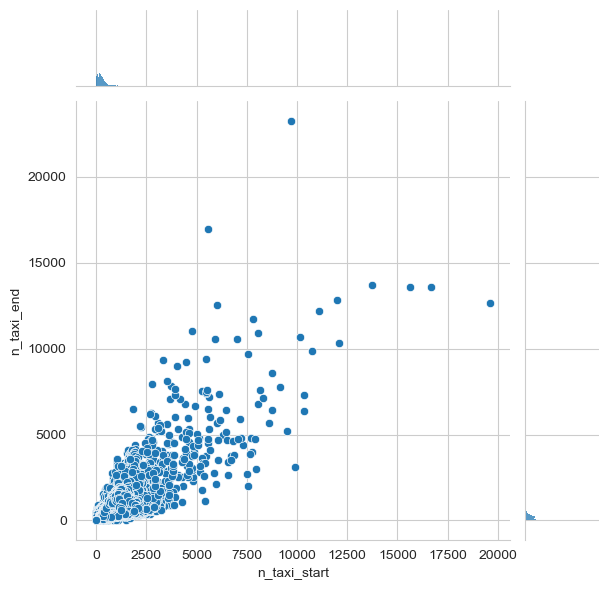

In [371]:
sns.jointplot(x='n_taxi_start', y='n_taxi_end', data=main_df, kind='scatter');

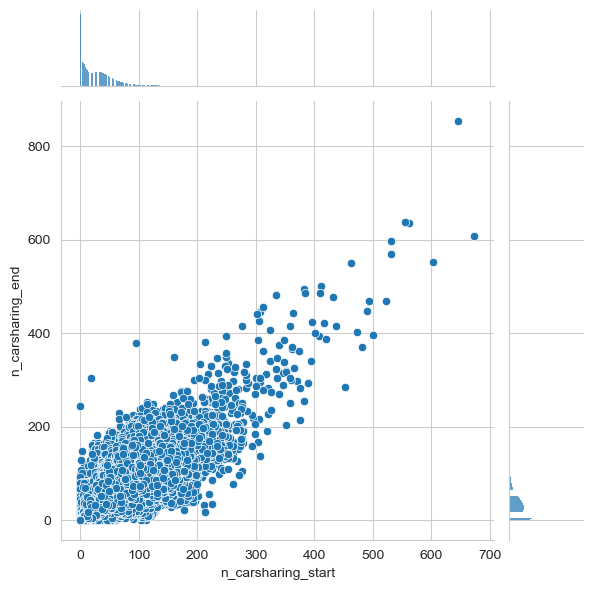

In [373]:
sns.jointplot(x='n_carsharing_start', y='n_carsharing_end', data=main_df, kind='scatter');

В данных нет ошибок, но есть присутствие больших значений, не думаю что имеет смысл их обрабатывать

## 6. Постройте матрицу корреляций числовых переменных.

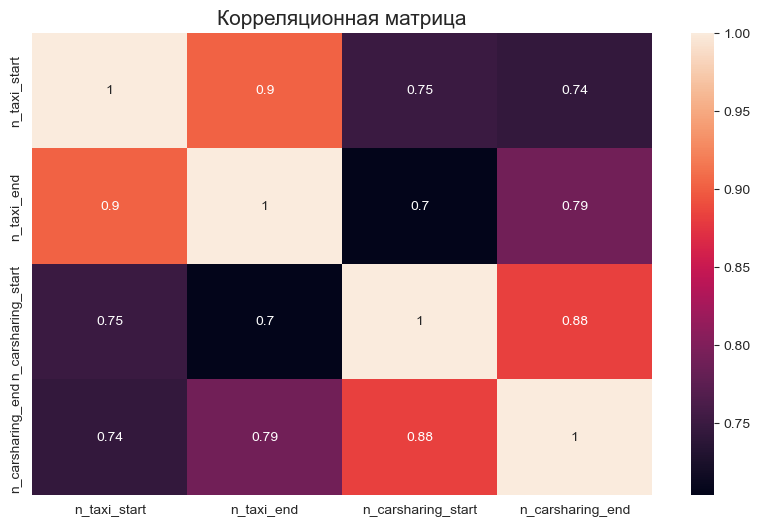

In [401]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.heatmap(data=main_df[['n_taxi_start','n_taxi_end', 'n_carsharing_start', 'n_carsharing_end']].corr(), ax=ax , annot=True)
ax.set_title('Корреляционная матрица', fontsize=15);

Мы наблюдаем сильную положительную корреляцию между признаками поездок в такси и каршеринге

## 7. Визуализируйте данные (например, с помощью matplotlib и seaborn).

постройте гистограммы распределения числовых переменных

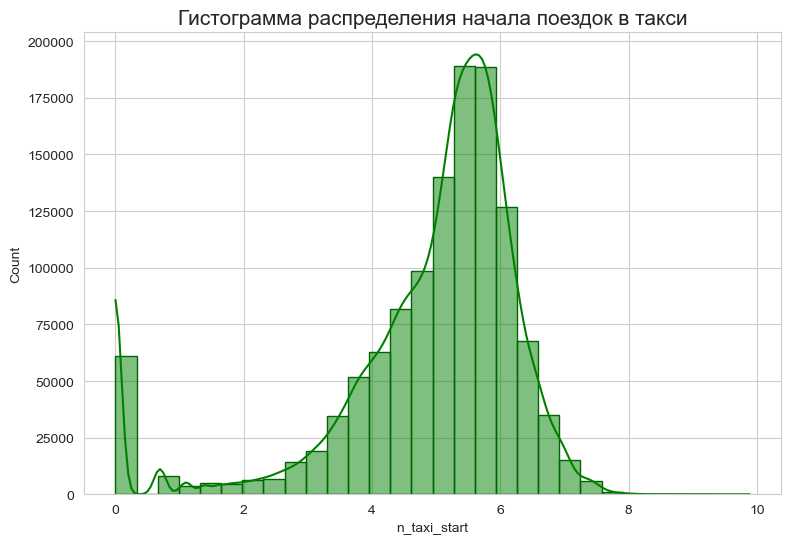

In [414]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Гистограмма распределения начала поездок в такси', fontsize=15)
sns.histplot(np.log1p(main_df.n_taxi_start),
             bins=30,
             ax=ax,
             color='green',
             edgecolor='darkgreen',
             kde=True
            );

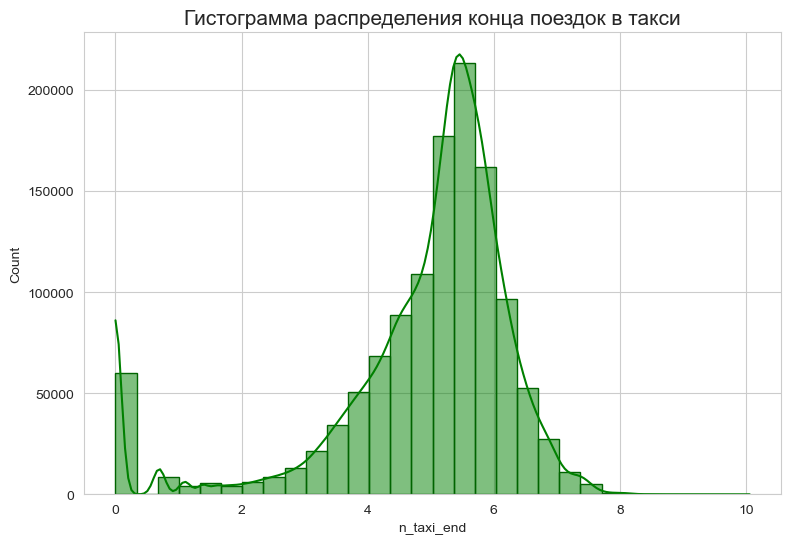

In [416]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Гистограмма распределения конца поездок в такси', fontsize=15)
sns.histplot(np.log1p(main_df.n_taxi_end),
             bins=30,
             ax=ax,
             color='green',
             edgecolor='darkgreen',
             kde=True
            );

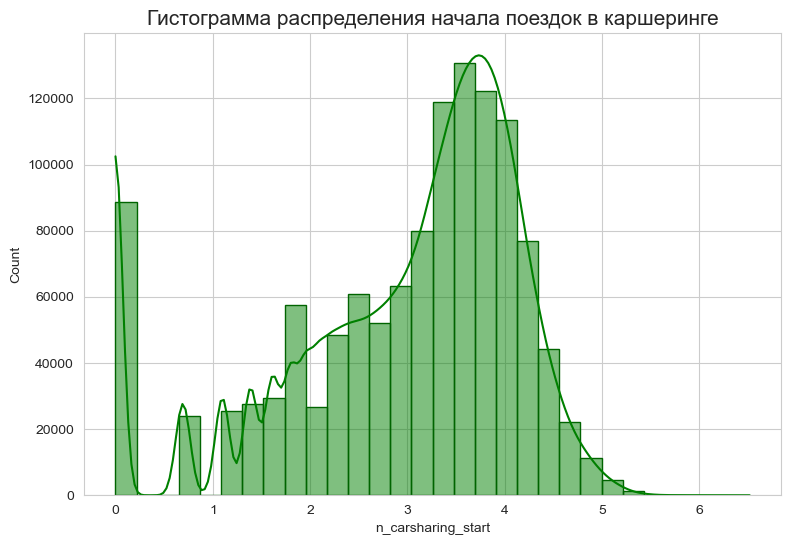

In [420]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Гистограмма распределения начала поездок в каршеринге', fontsize=15)
sns.histplot(np.log1p(main_df.n_carsharing_start),
             bins=30,
             ax=ax,
             color='green',
             edgecolor='darkgreen',
             kde=True
            );

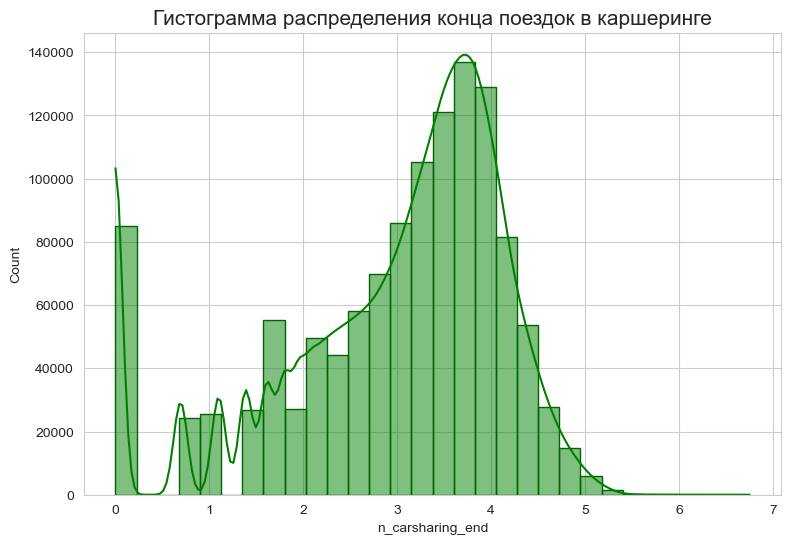

In [422]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Гистограмма распределения конца поездок в каршеринге', fontsize=15)
sns.histplot(np.log1p(main_df.n_carsharing_end),
             bins=30,
             ax=ax,
             color='green',
             edgecolor='darkgreen',
             kde=True
            );

проверьте попарные связи переменных друг с другом (например, с помощью scatterplot) и с целевой переменной

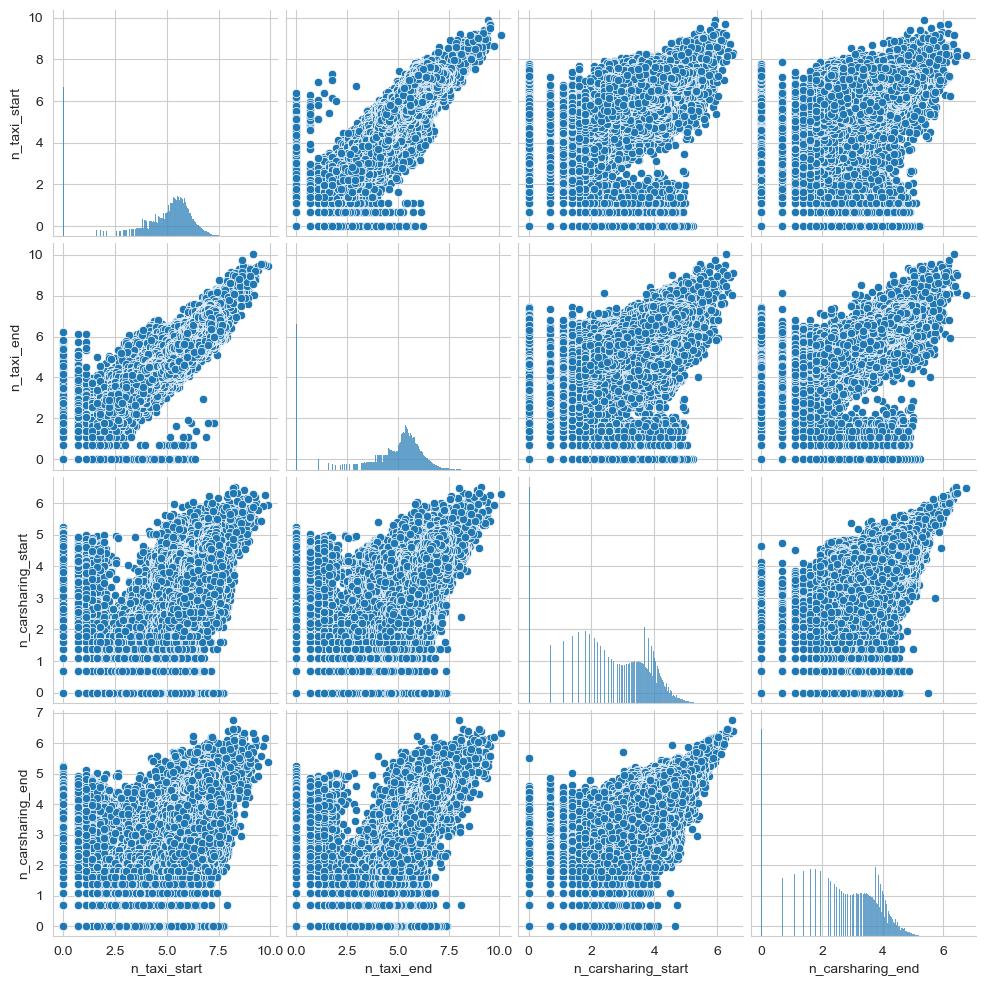

In [425]:
sns.pairplot(np.log1p(main_df[['n_taxi_start','n_taxi_end', 'n_carsharing_start', 'n_carsharing_end']]));

Мой вывод:
в большинстве распределений имеем восходящее линейное распределение, тоесть имеем положительную корреляцию между данными признаками

## 8. По возможности попробуйте задать какие-нибудь вопросы и ответить на них, используя ваши данные. Постройте необходимые сводные таблицы и графики.

Интересно было бы узнать совпадает ли распределение спроса на такси и каршеринг по районам москвы, а также узнать в какие месяцы больше популярно такси, а в какие каршеринг

In [113]:
def get_plot(df, column_name, title):
    df_draw = df.groupby(['district_name'])[column_name] \
                .sum() \
                .sort_values(ascending=False) \
                .head(5)
    
    plt.pie(df_draw, 
            labels=df_draw.index, 
            autopct='%1.1f%%', 
            colors=sns.color_palette('pastel')[0:5],
            textprops={'family': 'monospace'}, 
            startangle=90)
    
    plt.title(title, fontweight='bold', family='monospace')

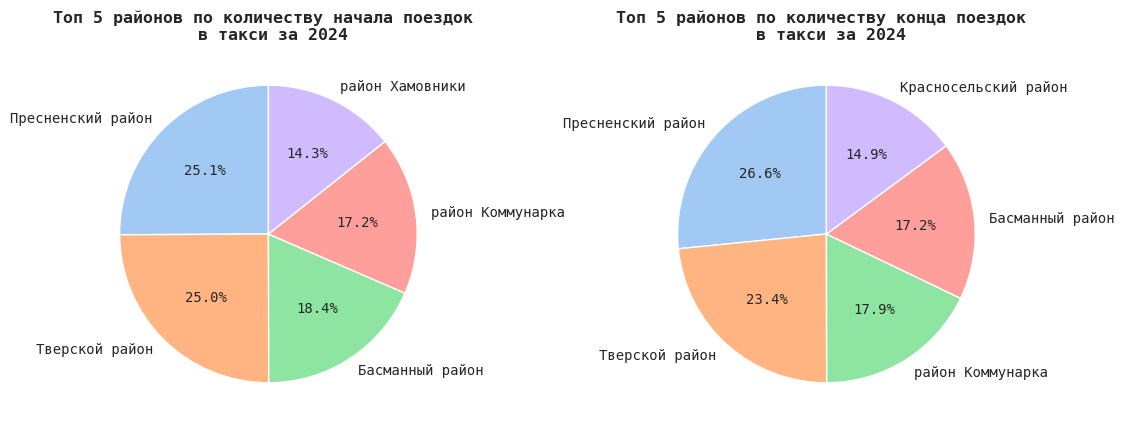

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.subplots_adjust(wspace=0.5)

plt.sca(axes[0])
get_plot(main_df, 'n_taxi_start', 'Топ 5 районов по количеству начала поездок \n в такси за 2024')

plt.sca(axes[1])
get_plot(main_df, 'n_taxi_end', 'Топ 5 районов по количеству конца поездок \n в такси за 2024')

plt.show()

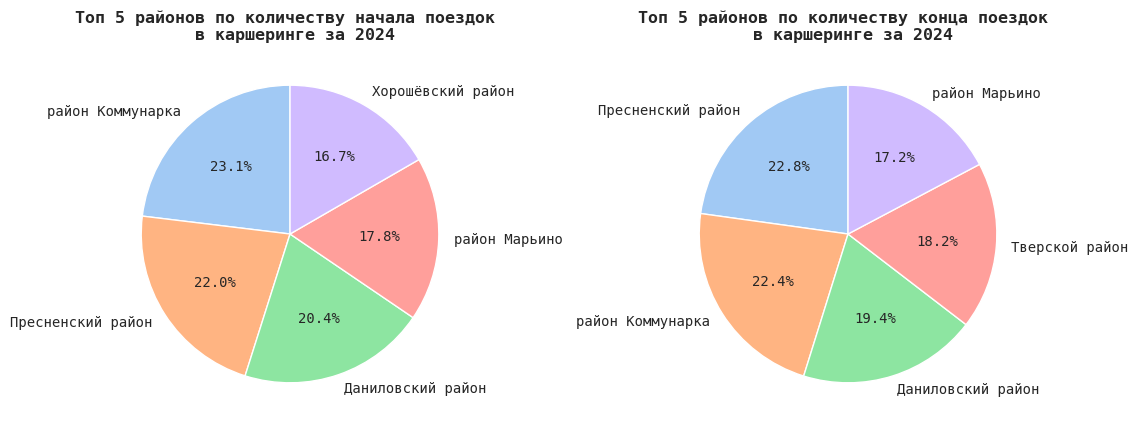

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.subplots_adjust(wspace=0.5)

plt.sca(axes[0])
get_plot(main_df, 'n_carsharing_start', 'Топ 5 районов по количеству начала поездок \n в каршеринге за 2024')

plt.sca(axes[1])
get_plot(main_df, 'n_carsharing_end', 'Топ 5 районов по количеству конца поездок \n в каршеринге за 2024')

plt.show()

Мы можем видеть разницу в районах: люди чаще выезжают из коммунарки, думаю это связано с тем, что добираться из данного региона долго и когда жители утром опаздывают на работу, они чаще берут каршеринг, тогда как в вечернее время, когда добираются домой, могут позволить себе более экономный - общественный вид транспорта

In [197]:
main_df['month_name'] = main_df['timestamp'].dt.strftime('%B')

In [205]:
main_df['month_name'] = main_df['timestamp'].dt.strftime('%B').map({
    'January': 'Январь', 'February': 'Февраль', 'March': 'Март',
    'April': 'Апрель', 'May': 'Май', 'June': 'Июнь',
    'July': 'Июль', 'August': 'Август', 'September': 'Сентябрь',
    'October': 'Октябрь', 'November': 'Ноябрь', 'December': 'Декабрь'
})


In [250]:
df_draw_taxi = main_df.groupby('month_name').agg({'n_taxi_start': 'sum',
                                                 'timestamp': 'min'}) \
        .sort_values(by='timestamp')


In [257]:
df_draw_carsharing  = main_df.groupby('month_name').agg({'n_carsharing_start': 'sum',
                                                 'timestamp': 'min'}) \
        .sort_values(by='timestamp')

In [259]:
df_draw_carsharing

,n_carsharing_start,timestamp
month_name,,
Январь,2708394,2024-01-01
Февраль,2430919,2024-02-01
Март,3116449,2024-03-01
Апрель,3101246,2024-04-01
Май,3253541,2024-05-01
Июнь,3377702,2024-06-01
Июль,3357462,2024-07-01
Август,3495125,2024-08-01
Сентябрь,3487123,2024-09-01


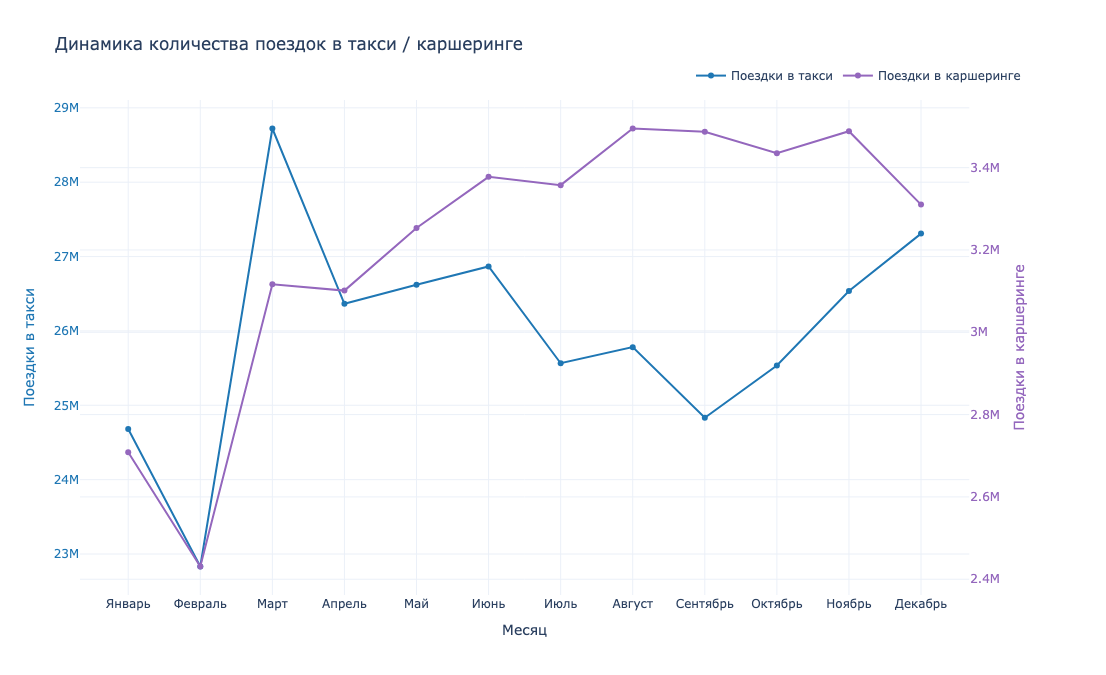

In [269]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(
        x=df_draw_taxi.index,
        y=df_draw_taxi.n_taxi_start,
        name="Поездки в такси",
        line=dict(color='#1f77b4'),
    ),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=df_draw_carsharing.index,
        y=df_draw_carsharing.n_carsharing_start,
        name="Поездки в каршеринге",
        line=dict(color='#9467bd'),
    ),
    secondary_y=True
)

fig.update_layout(
    title_text="Динамика количества поездок в такси / каршеринге",
    width=1100,
    height=675,
    template='plotly_white',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.update_yaxes(
    title_text="Поездки в такси",
    title_font=dict(color='#1f77b4'),
    tickfont=dict(color='#1f77b4'),
    secondary_y=False
)

fig.update_yaxes(
    title_text="Поездки в каршеринге",
    title_font=dict(color='#9467bd'),
    tickfont=dict(color='#9467bd'),
    secondary_y=True
)

fig.update_xaxes(title_text="Месяц")

fig.show()

## 9. Сделайте развернутые выводы.

Думаю нам имеет больший смысл анализировать временные данные, чем искать взаимосвязь между поездками в такси в каршеринге, когда понятно, что она и так линейна.
Думаю в нашем случае куда более важно с целью предсказания спроса на 2025 год оценивать динамику спроса на такси и каршеринга, которую мы можем отследить на последнем графике. Мы можем заметить, повышенный спрос с началом весны и до конца лета на каршеринг, тогда как такси имеет нисходящую динамику которая меняется на противоположную для такси и каршеринга в сентябре 2024 года.